# PubMed Bioinformatics Abstracts — Analysis

Primary analysis and data exploration for the **174,154** bioinformatics abstracts dataset (2020–2026) collected in `bio_abs.ipynb` and published on HuggingFace.

**Dataset:** [yashm/pubmed-bioinformatics-abstracts](https://huggingface.co/datasets/yashm/pubmed-bioinformatics-abstracts)  
**Collection notebook:** [bio_abs.ipynb](https://github.com/yashmgupta/pubmed-bioinformatics-abstracts/blob/main/bio_abs.ipynb)  
**Curated by:** Dr. Yash M Gupta

**Pipeline:**
1. Install dependencies & load dataset
2. Exploratory Data Analysis (EDA)
3. Text preprocessing & quality checks
4. Prepare data for fine-tuning (tokenization)
5. Fine-tune a small causal LM (DistilGPT-2)
6. Test generation

## Step 1 — Install Dependencies & Load Dataset

In [1]:
%pip -q install datasets pandas matplotlib seaborn wordcloud transformers accelerate torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datasets import load_dataset

sns.set_theme(style="whitegrid")

# Load from local parquet if available, otherwise pull from HuggingFace Hub
PARQUET_PATH = Path("out/pubmed_bioinformatics_abstracts/parquet/train.parquet")
HF_REPO = "yashm/pubmed-bioinformatics-abstracts"

if PARQUET_PATH.exists():
    ds = load_dataset("parquet", data_files=str(PARQUET_PATH), split="train")
    print(f"Loaded from local: {PARQUET_PATH}")
else:
    ds = load_dataset(HF_REPO, split="train")
    print(f"Loaded from HuggingFace Hub: {HF_REPO}")

df = ds.to_pandas()
print(f"Records: {len(df):,}")
print(f"Columns: {list(df.columns)}")
df.head(3)

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating train split: 174154 examples [00:01, 173052.63 examples/s]


Loaded from local: out\pubmed_bioinformatics_abstracts\parquet\train.parquet
Records: 174,154
Columns: ['pmid', 'title', 'abstract', 'year', 'journal', 'doi', 'source', 'slice']


,pmid,title,abstract,year,journal,doi,source,slice
0,34745570,From research to rapid response: mass COVID-19...,The COVID-19 pandemic has posed and is continu...,2020,F1000Research,10.12688/f1000research.27497.1,pubmed,2020-01
1,34367618,The ELIXIR Human Copy Number Variations Commun...,Copy number variations (CNVs) are major causat...,2020,F1000Research,10.12688/f1000research.24887.1,pubmed,2020-01
2,34007304,Potential Genes Associated with the Survival o...,Lung adenocarcinoma (LUAD) is the most common ...,2020,Computational and mathematical methods in medi...,10.1155/2020/7103412,pubmed,2020-01


## Step 2 — Exploratory Data Analysis

In [3]:
# Basic stats
df["abstract_len"] = df["abstract"].str.len()
df["word_count"] = df["abstract"].str.split().str.len()

print("=== Abstract Length (chars) ===")
print(df["abstract_len"].describe().round(1))
print("\n=== Word Count ===")
print(df["word_count"].describe().round(1))
print(f"\nMissing DOIs: {(df['doi'] == '').sum():,} / {len(df):,}")
print(f"Unique journals: {df['journal'].nunique():,}")
print(f"Year range: {df['year'].min()} – {df['year'].max()}")

=== Abstract Length (chars) ===
count    174154.0
mean       1575.3
std         484.0
min           3.0
25%        1259.0
50%        1544.0
75%        1837.0
max        7617.0
Name: abstract_len, dtype: float64

=== Word Count ===
count    174154.0
mean        216.8
std          67.4
min           1.0
25%         172.0
50%         211.0
75%         251.0
max        1211.0
Name: word_count, dtype: float64

Missing DOIs: 622 / 174,154
Unique journals: 3,460
Year range: 2019 – 2026


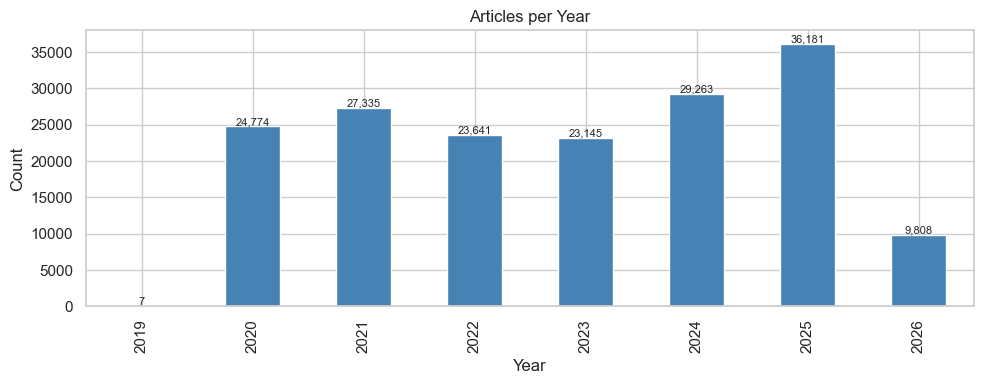

In [4]:
# Articles per year
year_counts = df["year"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
year_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Articles per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
for i, v in enumerate(year_counts):
    ax.text(i, v + 200, f"{v:,}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

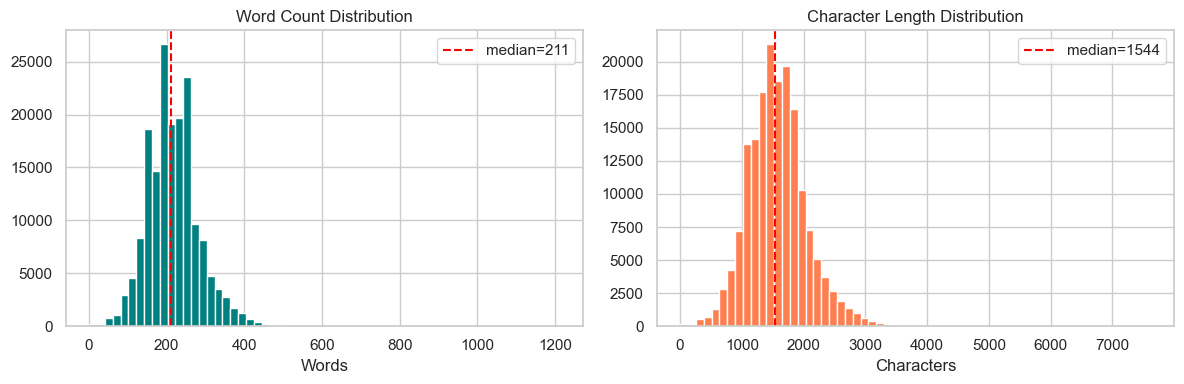

In [5]:
# Abstract length distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["word_count"].hist(bins=60, ax=axes[0], color="teal", edgecolor="white")
axes[0].set_title("Word Count Distribution")
axes[0].set_xlabel("Words")
axes[0].axvline(df["word_count"].median(), color="red", linestyle="--", label=f"median={df['word_count'].median():.0f}")
axes[0].legend()

df["abstract_len"].hist(bins=60, ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Character Length Distribution")
axes[1].set_xlabel("Characters")
axes[1].axvline(df["abstract_len"].median(), color="red", linestyle="--", label=f"median={df['abstract_len'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

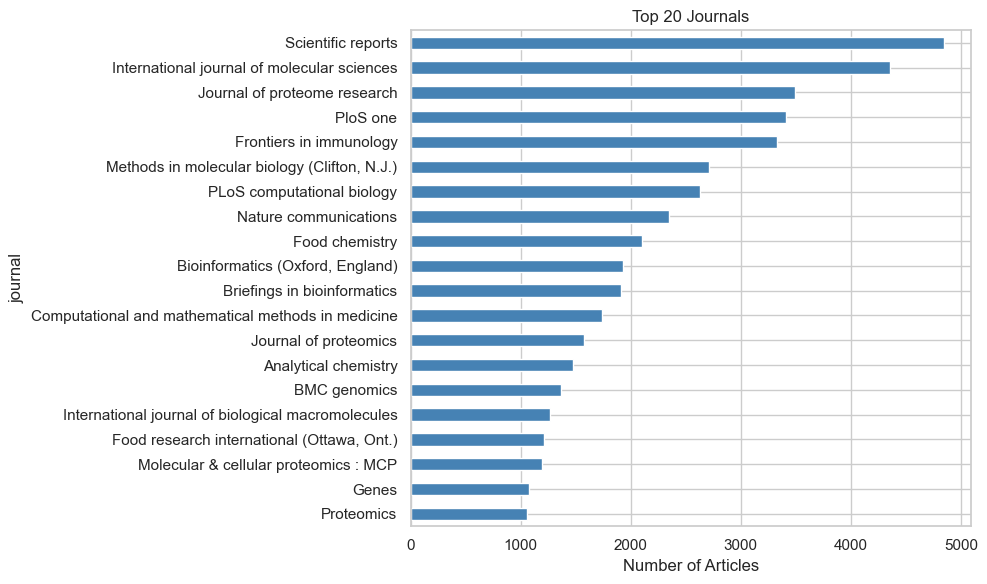

In [6]:
# Top 20 journals
top_journals = df["journal"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
top_journals.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 20 Journals")
ax.set_xlabel("Number of Articles")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

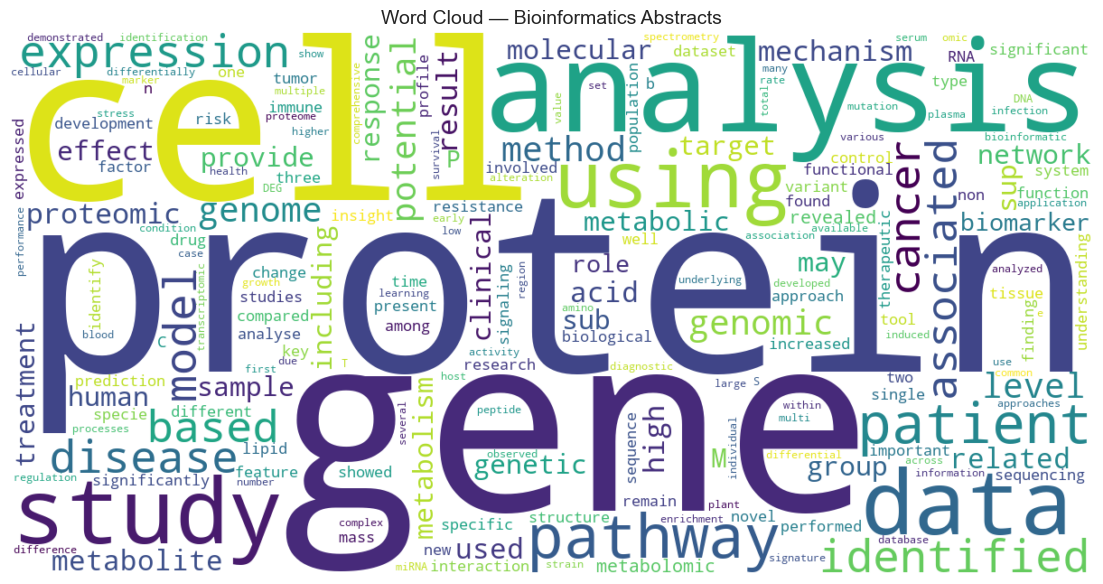

In [7]:
# Word cloud of abstracts
from wordcloud import WordCloud

text_sample = " ".join(df["abstract"].sample(min(10000, len(df)), random_state=42))

wc = WordCloud(width=1200, height=600, max_words=200, background_color="white",
               colormap="viridis", collocations=False).generate(text_sample)

fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Word Cloud — Bioinformatics Abstracts", fontsize=14)
plt.tight_layout()
plt.show()

## Step 3 — Text Quality Checks & Preprocessing

In [8]:
import re

# Check for duplicates
dup_pmid = df["pmid"].duplicated().sum()
dup_abstract = df["abstract"].duplicated().sum()
print(f"Duplicate PMIDs: {dup_pmid:,}")
print(f"Duplicate abstracts: {dup_abstract:,}")

# Remove exact duplicate abstracts (keep first)
df_clean = df.drop_duplicates(subset="abstract", keep="first").copy()
print(f"After dedup: {len(df_clean):,} (removed {len(df) - len(df_clean):,})")

# Filter very short or very long abstracts
MIN_WORDS = 30
MAX_WORDS = 1000
before = len(df_clean)
df_clean = df_clean[(df_clean["word_count"] >= MIN_WORDS) & (df_clean["word_count"] <= MAX_WORDS)]
print(f"After length filter ({MIN_WORDS}-{MAX_WORDS} words): {len(df_clean):,} (removed {before - len(df_clean):,})")

print(f"\nFinal clean dataset: {len(df_clean):,} records")

Duplicate PMIDs: 51,998
Duplicate abstracts: 52,011
After dedup: 122,143 (removed 52,011)
After length filter (30-1000 words): 121,927 (removed 216)

Final clean dataset: 121,927 records
